# Parte 3 — Experimentos de Mejora

## Experimentos
| # | Nombre | Hipótesis |
|---|--------|-----------|
| 1 | Ablation study por señal | ¿Resp mete ruido? ¿EDA+Temp es suficiente? |
| 2 | Modelo especializado en detectables | ¿El AUC sube si eliminamos sujetos sin señal? |
| 3 | Zona precursora más corta (15s) | ¿Ventanas más cercanas al onset tienen señal más limpia? |
| 4 | Umbral adaptativo por sujeto | ¿Calibrar el umbral mejora Recall sin perder precisión? |

## 0. Setup — carga de datos y funciones comunes

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from scipy.signal import find_peaks, butter, filtfilt
from scipy import stats as scipy_stats
import pickle, os, warnings
warnings.filterwarnings('ignore')

WESAD_PATH = 'WESAD'
SEED       = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

#Constantes 
FS, FS_10, DS   = 700, 10, 70
WINDOW          = 600      # 60s
STRIDE          = 50       # 5s
STRESS          = 2
VALID_LBLS      = [1, 2, 3, 4]
NEG_RATIO       = 3
BATCH           = 32
MAX_EP          = 100
PATIENCE        = 10

# Grupos de detectabilidad 
DETECTABLES    = ['S4','S6','S9','S10','S11','S13','S14']
MODERADOS      = ['S3','S8','S16','S17']
NO_DETECT      = ['S2','S5','S7','S15']
ALL_SUBJECTS   = ['S2','S3','S4','S5','S6','S7','S8','S9',
                  'S10','S11','S13','S14','S15','S16','S17']

# Baseline Parte 2
BASELINE_AUC = {
    'S2':0.222,'S3':0.725,'S4':0.856,'S5':0.318,'S6':0.793,
    'S7':0.543,'S8':0.684,'S9':0.954,'S10':0.781,'S11':0.828,
    'S13':0.826,'S14':0.912,'S15':0.373,'S16':0.587,'S17':0.695
}

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.21.0
GPU: False


In [ ]:
#Funciones comunes 

def bandpass(sig, lo=0.5, hi=40.0, fs=700, order=3):
    nyq = fs/2
    b,a = butter(order, [lo/nyq, hi/nyq], btype='band')
    return filtfilt(b, a, sig.flatten())

def hrv_features(ecg, fs=700):
    try:
        ef = bandpass(ecg, fs=fs)
        pk,_ = find_peaks(ef, distance=int(0.3*fs), height=np.percentile(ef,75))
        if len(pk)<3: return np.array([np.nan]*3)
        rr = np.diff(pk)/fs*1000
        rr = rr[(rr>300)&(rr<2000)]
        if len(rr)<2: return np.array([np.nan]*3)
        return np.array([60000/np.mean(rr),
                         np.sqrt(np.mean(np.diff(rr)**2)),
                         np.mean(np.abs(np.diff(rr))>50)*100])
    except: return np.array([np.nan]*3)

def build_gru(window, n_ts, n_hrv=3, units=32, drop=0.3):
    inp_ts  = keras.Input(shape=(window, n_ts))
    x = layers.GRU(units, return_sequences=True)(inp_ts)
    x = layers.Dropout(drop)(x)
    x = layers.GRU(units//2)(x)
    x = layers.Dropout(drop)(x)
    inp_hrv = keras.Input(shape=(n_hrv,))
    h = layers.Dense(16, activation='relu')(inp_hrv)
    h = layers.Dropout(drop)(h)
    m = layers.Concatenate()([x, h])
    m = layers.Dense(32, activation='relu')(m)
    m = layers.Dropout(drop)(m)
    out = layers.Dense(1, activation='sigmoid')(m)
    model = Model([inp_ts, inp_hrv], out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_eval(Xts_tr, Xhr_tr, y_tr, Xts_te, Xhr_te, y_te,
               n_ts_feats, threshold=0.5):
    hm,hs = np.nanmean(Xhr_tr,0), np.nanstd(Xhr_tr,0)+1e-8
    Xhr_tr = np.nan_to_num((Xhr_tr-hm)/hs, nan=0.0)
    Xhr_te = np.nan_to_num((Xhr_te-hm)/hs, nan=0.0)
    cw = dict(zip(*[np.unique(y_tr,return_counts=True)[0],
                    compute_class_weight('balanced',classes=np.unique(y_tr),y=y_tr)]))
    keras.backend.clear_session()
    model = build_gru(WINDOW, n_ts_feats)
    cbs = [EarlyStopping(patience=PATIENCE, restore_best_weights=True, monitor='val_loss'),
           ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5)]
    model.fit([Xts_tr,Xhr_tr], y_tr, epochs=MAX_EP, batch_size=BATCH,
              validation_split=0.15, class_weight=cw, callbacks=cbs, verbose=0)
    prob = model.predict([Xts_te,Xhr_te], verbose=0).flatten()
    pred = (prob >= threshold).astype(int)
    roc  = roc_auc_score(y_te, prob) if len(np.unique(y_te))>1 else np.nan
    pr   = average_precision_score(y_te, prob) if len(np.unique(y_te))>1 else np.nan
    rec  = recall_score(y_te, pred, zero_division=0)
    f1   = f1_score(y_te, pred, zero_division=0)
    return {'roc':roc,'pr':pr,'recall':rec,'f1':f1,'prob':prob}

def print_summary(results, name):
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(f'{"Sujeto":8} {"ROC-AUC":>9} {"PR-AUC":>8} {"Recall":>8} {"F1":>8} {"vs Baseline":>12}')
    print('-'*58)
    for s,m in results.items():
        delta = m['roc'] - BASELINE_AUC.get(s, m['roc'])
        flag  = '⬆' if delta > 0.02 else ('⬇' if delta < -0.02 else '≈')
        print(f'{s:8} {m["roc"]:>9.3f} {m["pr"]:>8.3f} {m["recall"]:>8.3f} '
              f'{m["f1"]:>8.3f} {delta:>+10.3f} {flag}')
    vals = [m['roc'] for m in results.values() if not np.isnan(m['roc'])]
    print('-'*58)
    print(f'{"Media":8} {np.mean(vals):>9.3f} ± {np.std(vals):.3f}')
    base_vals = [BASELINE_AUC[s] for s in results if s in BASELINE_AUC]
    print(f'Baseline:  {np.mean(base_vals):.3f} → Delta: {np.mean(vals)-np.mean(base_vals):+.3f}')

print('Funciones listas.')

Funciones listas.


In [ ]:
#Cargar dataset base 
raw      = np.load(f'{WESAD_PATH}/fase_B_hybrid_s50.npz', allow_pickle=True)
subjs_B  = list(raw['subjects'])
windows_B = {s: (raw[f'{s}_Xts'], raw[f'{s}_Xhr'], raw[f'{s}_y']) for s in subjs_B}

total = sum(len(windows_B[s][2]) for s in subjs_B)
print(f'Dataset cargado: {len(subjs_B)} sujetos, {total} ventanas')
print(f'Shape Xts: {windows_B[subjs_B[0]][0].shape}  (ventanas, pasos, señales)')
print(f'Shape Xhr: {windows_B[subjs_B[0]][1].shape}  (ventanas, HRV features)')

Dataset cargado: 15 sujetos, 360 ventanas
Shape Xts: (24, 600, 3)  (ventanas, pasos, señales)
Shape Xhr: (24, 3)  (ventanas, HRV features)



## Experimento 1 — Ablation Study por Señal

**Hipótesis:** el análisis estadístico (Mann-Whitney) mostró que EDA slope y Temp son
las features más discriminativas. Resp range fue significativo pero en dirección
contraintuitiva (mayor en no detectables). Es posible que Resp meta ruido.

**Método:** entrenamos GRU con 5 combinaciones de señales y comparamos AUC.


In [ ]:
# Índices de cada señal en el tensor 
SIGNAL_COMBOS = {
    'Solo EDA':          [0],
    'Solo Temp':         [1],
    'Solo Resp':         [2],
    'EDA + Temp':        [0, 1],
    'EDA+Temp+Resp (base)': [0, 1, 2],
}

ablation_results = {}   

for combo_name, sig_idx in SIGNAL_COMBOS.items():
    print(f'\nEntrenando: {combo_name} ({len(sig_idx)} señal/es)...')
    combo_res = {}
    for test_subj in subjs_B:
        train_subjs = [s for s in subjs_B if s != test_subj]
        # Seleccionar solo las señales de este combo
        Xts_tr = np.concatenate([windows_B[s][0][:,:,sig_idx] for s in train_subjs])
        Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
        y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
        Xts_te = windows_B[test_subj][0][:,:,sig_idx]
        Xhr_te = windows_B[test_subj][1]
        y_te   = windows_B[test_subj][2]
        metrics = train_eval(Xts_tr, Xhr_tr, y_tr, Xts_te, Xhr_te, y_te,
                             n_ts_feats=len(sig_idx))
        combo_res[test_subj] = metrics
    ablation_results[combo_name] = combo_res
    aucs = [combo_res[s]['roc'] for s in subjs_B]
    print(f'  → AUC media: {np.nanmean(aucs):.3f} ± {np.nanstd(aucs):.3f}')

# Resumen detallado por combinación
for name, res in ablation_results.items():
    print_summary(res, f'EXP 1 — {name}')


Entrenando: Solo EDA (1 señal/es)...

  → AUC media: 0.603 ± 0.224

Entrenando: Solo Temp (1 señal/es)...
  → AUC media: 0.653 ± 0.248

Entrenando: Solo Resp (1 señal/es)...
  → AUC media: 0.524 ± 0.231

Entrenando: EDA + Temp (2 señal/es)...
  → AUC media: 0.711 ± 0.273

Entrenando: EDA+Temp+Resp (base) (3 señal/es)...
  → AUC media: 0.627 ± 0.260

  EXP 1 — Solo EDA
Sujeto     ROC-AUC   PR-AUC   Recall       F1  vs Baseline
----------------------------------------------------------
S2           0.380    0.227    1.000    0.462     +0.158 ⬆
S3           0.769    0.427    1.000    0.480     +0.044 ⬆
S4           0.750    0.550    1.000    0.462     -0.106 ⬇
S5           0.315    0.209    1.000    0.480     -0.003 ≈
S6           0.481    0.255    0.000    0.000     -0.312 ⬇
S7           0.463    0.248    1.000    0.400     -0.080 ⬇
S8           0.676    0.354    0.667    0.471     -0.008 ≈
S9           0.769    0.464    0.000    0.000     -0.185 ⬇
S10          0.861    0.549    0.000  

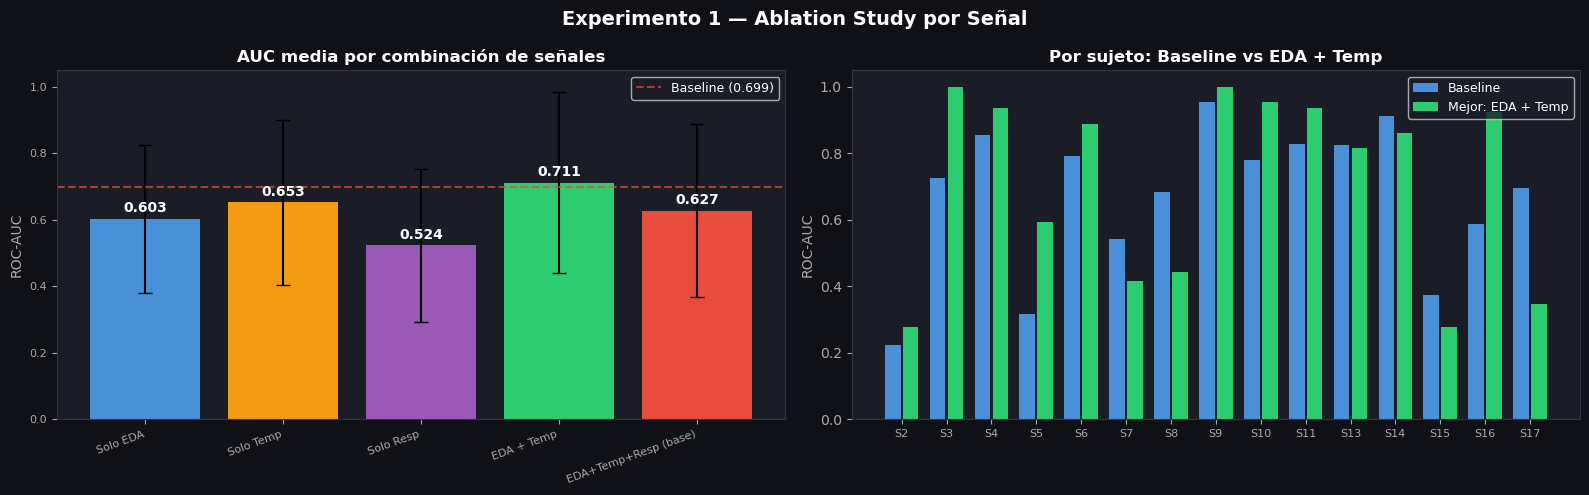

Mejor combinación: EDA + Temp (AUC=0.711)


In [6]:
# Gráfica comparativa Experimento 1
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0F1117')
for ax in axes: ax.set_facecolor('#1A1D26')

combo_names = list(ablation_results.keys())
colors_ab   = ['#4A90D9','#F39C12','#9B59B6','#2ECC71','#E74C3C']

# AUC media por combinación
means_ab = [np.nanmean([ablation_results[c][s]['roc'] for s in subjs_B]) for c in combo_names]
stds_ab  = [np.nanstd ([ablation_results[c][s]['roc'] for s in subjs_B]) for c in combo_names]
bars = axes[0].bar(combo_names, means_ab, yerr=stds_ab, capsize=5,
                   color=colors_ab, edgecolor='none',
                   error_kw={'color':'white','linewidth':1.5})
for bar, m in zip(bars, means_ab):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{m:.3f}', ha='center', color='white', fontsize=10, fontweight='bold')
axes[0].axhline(0.699, color='#E74C3C', linestyle='--', alpha=0.7, label='Baseline (0.699)')
axes[0].set_title('AUC media por combinación de señales', color='white', fontweight='bold')
axes[0].set_ylabel('ROC-AUC', color='#AAAAAA')
axes[0].tick_params(colors='#AAAAAA', labelsize=8); axes[0].spines[:].set_color('#333344')
axes[0].set_xticklabels(combo_names, rotation=20, ha='right', color='#AAAAAA')
axes[0].set_ylim(0, 1.05)
axes[0].legend(facecolor='#1A1D26', labelcolor='white', fontsize=9)

# AUC por sujeto para la mejor combinación vs baseline
best_combo = combo_names[np.argmax(means_ab)]
x = np.arange(len(subjs_B))
base_aucs = [BASELINE_AUC.get(s, 0) for s in subjs_B]
best_aucs = [ablation_results[best_combo][s]['roc'] for s in subjs_B]
axes[1].bar(x-0.2, base_aucs, width=0.35, label='Baseline', color='#4A90D9', edgecolor='none')
axes[1].bar(x+0.2, best_aucs, width=0.35, label=f'Mejor: {best_combo}', color='#2ECC71', edgecolor='none')
axes[1].set_xticks(x); axes[1].set_xticklabels(subjs_B, color='#AAAAAA', fontsize=8)
axes[1].set_title(f'Por sujeto: Baseline vs {best_combo}', color='white', fontweight='bold')
axes[1].tick_params(colors='#AAAAAA'); axes[1].spines[:].set_color('#333344')
axes[1].legend(facecolor='#1A1D26', labelcolor='white', fontsize=9)
axes[1].set_ylabel('ROC-AUC', color='#AAAAAA')
axes[1].set_ylim(0, 1.05)

fig.suptitle('Experimento 1 — Ablation Study por Señal', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/exp1_ablation.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f'Mejor combinación: {best_combo} (AUC={max(means_ab):.3f})')


## Experimento 2 — Modelo Especializado en Sujetos Detectables

**Hipótesis:** los 4 sujetos no detectables (S2, S5, S7, S15) no tienen señal
fisiológica anticipatoria. Al incluirlos en el entrenamiento, añaden ruido que
perjudica al modelo. Entrenando solo con los 7 detectables + 4 moderados (11 sujetos)
y evaluando LOSO dentro de ese subgrupo, el AUC debería subir.


In [7]:
exp2_results = {}

for exp_name, group in [
    ('2A — Solo detectables (7)',    DETECTABLES),
    ('2B — Detect+Moderados (11)',   DETECTABLES + MODERADOS)
]:
    # Filtrar solo sujetos del grupo que tienen datos
    group_avail = [s for s in group if s in subjs_B]
    print(f'\nEXP {exp_name} — {group_avail}')
    group_res = {}
    for test_subj in group_avail:
        train_subjs = [s for s in group_avail if s != test_subj]
        Xts_tr = np.concatenate([windows_B[s][0] for s in train_subjs])
        Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
        y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
        Xts_te, Xhr_te, y_te = windows_B[test_subj]
        metrics = train_eval(Xts_tr, Xhr_tr, y_tr, Xts_te, Xhr_te, y_te, n_ts_feats=3)
        group_res[test_subj] = metrics
        print(f'  {test_subj}: ROC={metrics["roc"]:.3f}')
    exp2_results[exp_name] = group_res
    print_summary(group_res, f'EXP {exp_name}')


EXP 2A — Solo detectables (7) — ['S4', 'S6', 'S9', 'S10', 'S11', 'S13', 'S14']
  S4: ROC=0.889
  S6: ROC=0.676
  S9: ROC=1.000
  S10: ROC=0.907
  S11: ROC=0.954
  S13: ROC=0.806
  S14: ROC=0.620

  EXP 2A — Solo detectables (7)
Sujeto     ROC-AUC   PR-AUC   Recall       F1  vs Baseline
----------------------------------------------------------
S4           0.889    0.594    1.000    0.857     +0.033 ⬆
S6           0.676    0.446    0.667    0.533     -0.117 ⬇
S9           1.000    1.000    1.000    1.000     +0.046 ⬆
S10          0.907    0.650    1.000    0.857     +0.126 ⬆
S11          0.954    0.818    1.000    0.857     +0.126 ⬆
S13          0.806    0.646    0.500    0.500     -0.020 ⬇
S14          0.620    0.331    0.000    0.000     -0.292 ⬇
----------------------------------------------------------
Media        0.836 ± 0.132
Baseline:  0.850 → Delta: -0.014

EXP 2B — Detect+Moderados (11) — ['S4', 'S6', 'S9', 'S10', 'S11', 'S13', 'S14', 'S3', 'S8', 'S16', 'S17']
  S4: ROC=0.43

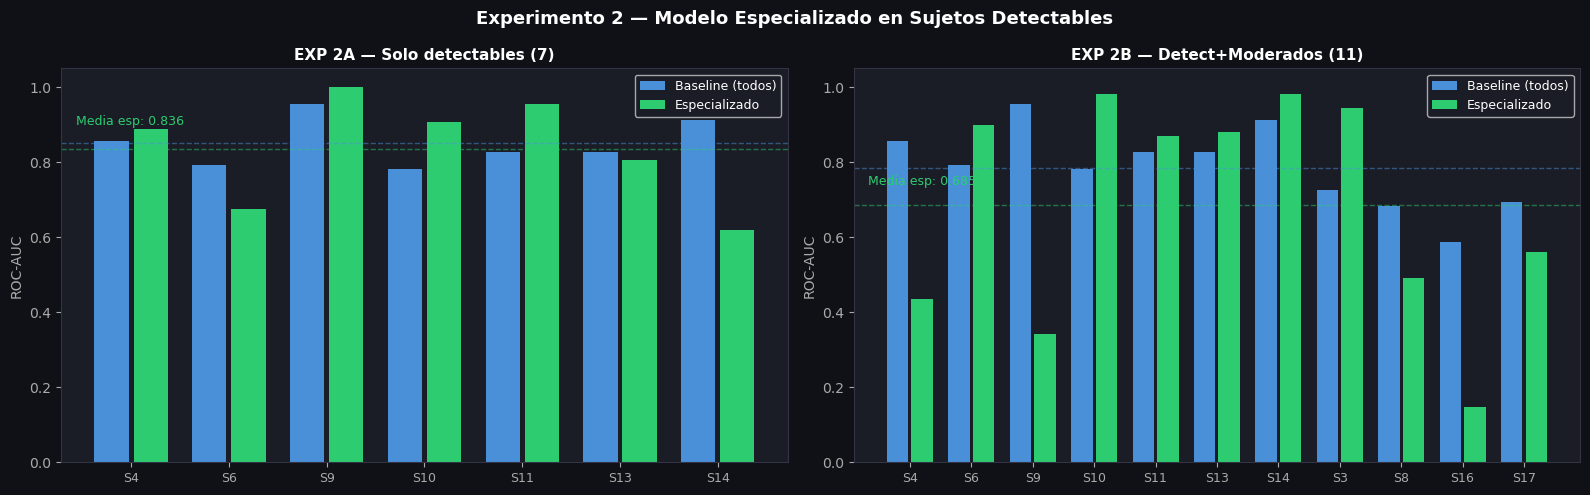

In [8]:
# Gráfica Experimento 2
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0F1117')
for ax in axes: ax.set_facecolor('#1A1D26')

for ax_i, (exp_name, group_res) in enumerate(exp2_results.items()):
    subjs_g  = list(group_res.keys())
    base_g   = [BASELINE_AUC.get(s, 0) for s in subjs_g]
    exp_g    = [group_res[s]['roc'] for s in subjs_g]
    x = np.arange(len(subjs_g))
    axes[ax_i].bar(x-0.2, base_g, width=0.35, label='Baseline (todos)', color='#4A90D9', edgecolor='none')
    axes[ax_i].bar(x+0.2, exp_g,  width=0.35, label='Especializado', color='#2ECC71', edgecolor='none')
    axes[ax_i].set_xticks(x); axes[ax_i].set_xticklabels(subjs_g, color='#AAAAAA', fontsize=9)
    axes[ax_i].set_title(f'EXP {exp_name}', color='white', fontweight='bold', fontsize=11)
    axes[ax_i].tick_params(colors='#AAAAAA'); axes[ax_i].spines[:].set_color('#333344')
    axes[ax_i].legend(facecolor='#1A1D26', labelcolor='white', fontsize=9)
    axes[ax_i].set_ylabel('ROC-AUC', color='#AAAAAA')
    axes[ax_i].set_ylim(0, 1.05)
    mean_exp  = np.nanmean(exp_g)
    mean_base = np.mean(base_g)
    axes[ax_i].axhline(mean_exp,  color='#2ECC71', linestyle='--', alpha=0.5, linewidth=1)
    axes[ax_i].axhline(mean_base, color='#4A90D9', linestyle='--', alpha=0.5, linewidth=1)
    axes[ax_i].text(0.02, mean_exp+0.02, f'Media esp: {mean_exp:.3f}',
                    transform=axes[ax_i].transAxes, color='#2ECC71', fontsize=9)

fig.suptitle('Experimento 2 — Modelo Especializado en Sujetos Detectables',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/exp2_especializado.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


## Experimento 3 — Zona Precursora Más Corta (15s)

**Hipótesis:** al usar 30s de zona precursora, incluimos ventanas que están muy lejos
del onset y pueden tener señal más débil. Reducir a 15s concentra las ventanas
más cercanas al onset, donde la activación fisiológica es más intensa y clara.

**Riesgo:** menos ventanas positivas por sujeto (~15 en lugar de 30),
lo que puede perjudicar el entrenamiento. Por eso comparamos explícitamente.

In [ ]:
from scipy import stats as scipy_stats

def build_windows_zone(df_s, ecg_700, zone_pasos, stride=STRIDE, window=WINDOW):
    labels  = df_s['Label'].values
    data    = df_s[['EDA','Temp','Resp']].values
    T       = len(labels)
    onsets  = [i for i in range(1,T) if labels[i]==STRESS and labels[i-1]!=STRESS]
    if not onsets: return None
    rng = np.random.default_rng(SEED)

    Xts_l, Xhr_l, y_l = [], [], []
    for onset in onsets:
        z_end = onset-1; z_start = max(window, onset-zone_pasos)
        for end_in in range(z_start, z_end+1, stride):
            start = end_in-window
            if start<0: continue
            seg = labels[start:end_in]
            if STRESS in seg or len(set(seg))>1: continue
            hrv = hrv_features(ecg_700[start*DS:(start+window)*DS])
            Xts_l.append(data[start:end_in]); Xhr_l.append(hrv); y_l.append(1)

    n_pos = sum(y_l)
    if n_pos == 0: return None

    forbidden = np.zeros(T, dtype=bool)
    for onset in onsets:
        fs_i=max(0,onset-zone_pasos); fe=onset
        while fe<T and labels[fe]==STRESS: fe+=1
        forbidden[fs_i:fe]=True
    negs=[]
    for start in range(0,T-window+1,stride*5):
        ei=start+window
        if forbidden[start:ei].any(): continue
        seg=labels[start:ei]
        if len(set(seg))>1 or seg[0]==STRESS: continue
        negs.append(start)
    n_neg=min(n_pos*NEG_RATIO,len(negs))
    if n_neg==0: return None
    for s in rng.choice(negs, size=n_neg, replace=False):
        hrv=hrv_features(ecg_700[s*DS:(s+window)*DS])
        Xts_l.append(data[s:s+window]); Xhr_l.append(hrv); y_l.append(0)

    return (np.array(Xts_l,dtype=np.float32),
            np.array(Xhr_l,dtype=np.float32),
            np.array(y_l,dtype=np.int32))


# Construir dataset con zona 15s
ZONE_15 = 150  # 15s * 10Hz
df_all  = pd.read_csv(f'{WESAD_PATH}/wesad_10hz_sin_hrv.csv')
windows_15s = {}
print('Construyendo ventanas con zona precursora = 15s...')
for subj in ALL_SUBJECTS:
    df_s = df_all[df_all['Subject_ID']==subj].reset_index(drop=True)
    path = f'{WESAD_PATH}/{subj}/{subj}.pkl'
    with open(path,'rb') as f: raw_pkl = pickle.load(f, encoding='latin1')
    ecg_700 = np.array(raw_pkl['signal']['chest']['ECG']).flatten()
    result = build_windows_zone(df_s, ecg_700, zone_pasos=ZONE_15)
    if result:
        windows_15s[subj] = result
        n_pos=(result[2]==1).sum(); n_neg=(result[2]==0).sum()
        print(f'  {subj}: {n_pos}pos/{n_neg}neg')

print(f'\nSujetos con datos: {list(windows_15s.keys())}')

Construyendo ventanas con zona precursora = 15s...
  S2: 3pos/9neg
  S3: 3pos/9neg
  S4: 3pos/9neg
  S5: 3pos/9neg
  S6: 3pos/9neg
  S7: 3pos/9neg
  S8: 3pos/9neg
  S9: 3pos/9neg
  S10: 3pos/9neg
  S11: 3pos/9neg
  S13: 3pos/9neg
  S14: 3pos/9neg
  S15: 3pos/9neg
  S16: 3pos/9neg
  S17: 3pos/9neg

Sujetos con datos: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']


Entrenando GRU con zona precursora 15s...
  S2: ROC=0.259
  S3: ROC=0.815
  S4: ROC=0.778
  S5: ROC=0.222
  S6: ROC=0.815
  S7: ROC=0.481
  S8: ROC=0.444
  S9: ROC=0.704
  S10: ROC=0.889
  S11: ROC=0.926
  S13: ROC=0.630
  S14: ROC=1.000
  S15: ROC=0.667
  S16: ROC=0.741
  S17: ROC=0.815

  EXP 3 — Zona 15s
Sujeto     ROC-AUC   PR-AUC   Recall       F1  vs Baseline
----------------------------------------------------------
S2           0.259    0.222    0.333    0.200     +0.037 ⬆
S3           0.815    0.556    1.000    0.600     +0.090 ⬆
S4           0.778    0.478    1.000    0.750     -0.078 ⬇
S5           0.222    0.216    0.000    0.000     -0.096 ⬇
S6           0.815    0.533    1.000    0.750     +0.022 ⬆
S7           0.481    0.287    0.333    0.222     -0.062 ⬇
S8           0.444    0.273    0.333    0.250     -0.240 ⬇
S9           0.704    0.421    0.000    0.000     -0.250 ⬇
S10          0.889    0.639    0.667    0.667     +0.108 ⬆
S11          0.926    0.806    1.000    0.

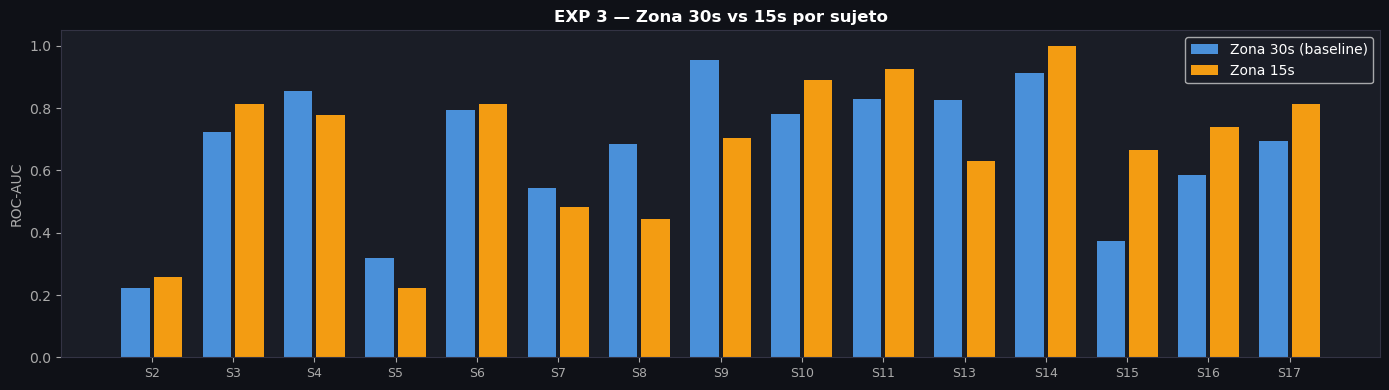

In [10]:
# Entrenar LOSO con zona 15s
print('Entrenando GRU con zona precursora 15s...')
subjs_15 = list(windows_15s.keys())
exp3_results = {}

for test_subj in subjs_15:
    train_subjs = [s for s in subjs_15 if s != test_subj]
    if len(train_subjs) < 3: continue
    Xts_tr = np.concatenate([windows_15s[s][0] for s in train_subjs])
    Xhr_tr = np.concatenate([windows_15s[s][1] for s in train_subjs])
    y_tr   = np.concatenate([windows_15s[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te = windows_15s[test_subj]
    metrics = train_eval(Xts_tr, Xhr_tr, y_tr, Xts_te, Xhr_te, y_te, n_ts_feats=3)
    exp3_results[test_subj] = metrics
    print(f'  {test_subj}: ROC={metrics["roc"]:.3f}')

print_summary(exp3_results, 'EXP 3 — Zona 15s')

# Comparación 30s vs 15s por sujeto
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#0F1117'); ax.set_facecolor('#1A1D26')
common = [s for s in exp3_results if s in BASELINE_AUC]
x = np.arange(len(common))
ax.bar(x-0.2, [BASELINE_AUC[s] for s in common], width=0.35, label='Zona 30s (baseline)', color='#4A90D9')
ax.bar(x+0.2, [exp3_results[s]['roc'] for s in common], width=0.35, label='Zona 15s', color='#F39C12')
ax.set_xticks(x); ax.set_xticklabels(common, color='#AAAAAA', fontsize=9)
ax.set_title('EXP 3 — Zona 30s vs 15s por sujeto', color='white', fontweight='bold')
ax.tick_params(colors='#AAAAAA'); ax.spines[:].set_color('#333344')
ax.legend(facecolor='#1A1D26', labelcolor='white')
ax.set_ylabel('ROC-AUC', color='#AAAAAA'); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/exp3_zona15s.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


## Experimento 4 — Umbral Adaptativo por Sujeto

**Hipótesis:** el umbral fijo de 0.5 es subóptimo para muchos sujetos. Si calibramos
el umbral usando una partición de validación interna del training de cada fold,
podemos mejorar Recall sin comprometer F1.

**Método:** dentro de cada fold LOSO, separamos el 15% del training como
validación interna. Entrenamos el modelo, buscamos el umbral que maximiza F1
en esa validación, y lo aplicamos al test.

**Nota:** el AUC no cambia con el umbral (AUC es independiente del umbral),
pero Recall, Precision y F1 sí cambian. Este experimento mejora las métricas
de decisión, no el poder discriminativo.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as skf1

def find_best_threshold(y_val, prob_val):
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_t, best_f1 = 0.5, 0
    for t in thresholds:
        pred = (prob_val >= t).astype(int)
        f1   = skf1(y_val, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


print('Entrenando GRU con umbral adaptativo por sujeto...')
exp4_results = {}

for test_subj in subjs_B:
    train_subjs = [s for s in subjs_B if s != test_subj]
    Xts_tr_all = np.concatenate([windows_B[s][0] for s in train_subjs])
    Xhr_tr_all = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr_all   = np.concatenate([windows_B[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te = windows_B[test_subj]

    # Normalizar HRV
    hm,hs = np.nanmean(Xhr_tr_all,0), np.nanstd(Xhr_tr_all,0)+1e-8
    Xhr_n = np.nan_to_num((Xhr_tr_all-hm)/hs, nan=0.0)
    Xhr_te_n = np.nan_to_num((Xhr_te-hm)/hs, nan=0.0)

    # Separar validación interna para calibrar umbral
    idx = np.arange(len(y_tr_all))
    idx_tr, idx_val = train_test_split(idx, test_size=0.15,
                                        stratify=y_tr_all, random_state=SEED)
    Xts_tr, Xhr_tr, y_tr = Xts_tr_all[idx_tr], Xhr_n[idx_tr], y_tr_all[idx_tr]
    Xts_val, Xhr_val, y_val = Xts_tr_all[idx_val], Xhr_n[idx_val], y_tr_all[idx_val]

    cw = dict(zip(*[np.unique(y_tr,return_counts=True)[0],
                    compute_class_weight('balanced',classes=np.unique(y_tr),y=y_tr)]))
    keras.backend.clear_session()
    model = build_gru(WINDOW, 3)
    cbs = [EarlyStopping(patience=PATIENCE, restore_best_weights=True, monitor='val_loss'),
           ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5)]
    model.fit([Xts_tr,Xhr_tr], y_tr, epochs=MAX_EP, batch_size=BATCH,
              validation_data=([Xts_val,Xhr_val], y_val),
              class_weight=cw, callbacks=cbs, verbose=0)

    # Calibrar umbral en validación interna
    prob_val = model.predict([Xts_val, Xhr_val], verbose=0).flatten()
    best_t, val_f1 = find_best_threshold(y_val, prob_val)

    # Evaluar en test con umbral calibrado
    prob_te = model.predict([Xts_te, Xhr_te_n], verbose=0).flatten()
    roc = roc_auc_score(y_te, prob_te) if len(np.unique(y_te))>1 else np.nan
    pr  = average_precision_score(y_te, prob_te) if len(np.unique(y_te))>1 else np.nan
    pred_adapt = (prob_te >= best_t).astype(int)
    rec = recall_score(y_te, pred_adapt, zero_division=0)
    f1  = f1_score(y_te, pred_adapt, zero_division=0)

    exp4_results[test_subj] = {'roc':roc,'pr':pr,'recall':rec,'f1':f1,
                                'threshold':best_t,'val_f1':val_f1}
    print(f'  {test_subj}: ROC={roc:.3f} | umbral={best_t:.2f} | Recall={rec:.3f}')

print_summary(exp4_results, 'EXP 4 — Umbral Adaptativo')

# Umbrales aprendidos
print('\nUmbrales calibrados por sujeto:')
for s, m in exp4_results.items():
    print(f'  {s}: umbral={m["threshold"]:.2f}')

Entrenando GRU con umbral adaptativo por sujeto...
  S2: ROC=0.278 | umbral=0.55 | Recall=0.833
  S3: ROC=0.898 | umbral=0.65 | Recall=1.000
  S4: ROC=0.870 | umbral=0.35 | Recall=1.000
  S5: ROC=0.056 | umbral=0.30 | Recall=0.000
  S6: ROC=0.981 | umbral=0.55 | Recall=1.000
  S7: ROC=0.704 | umbral=0.30 | Recall=1.000
  S8: ROC=0.583 | umbral=0.45 | Recall=0.833
  S9: ROC=0.972 | umbral=0.25 | Recall=1.000
  S10: ROC=0.889 | umbral=0.20 | Recall=1.000
  S11: ROC=0.981 | umbral=0.40 | Recall=1.000
  S13: ROC=0.796 | umbral=0.75 | Recall=0.000
  S14: ROC=0.991 | umbral=0.30 | Recall=1.000
  S15: ROC=0.556 | umbral=0.45 | Recall=1.000
  S16: ROC=0.407 | umbral=0.40 | Recall=0.000
  S17: ROC=0.569 | umbral=0.50 | Recall=0.000

  EXP 4 — Umbral Adaptativo
Sujeto     ROC-AUC   PR-AUC   Recall       F1  vs Baseline
----------------------------------------------------------
S2           0.278    0.204    0.833    0.417     +0.056 ⬆
S3           0.898    0.636    1.000    0.632     +0.173 ⬆
S4

## Comparación Final — Todos los Experimentos


TABLA COMPARATIVA FINAL — TODOS LOS EXPERIMENTOS
Experimento                          N sujetos  AUC media      Std    Delta
---------------------------------------------------------------------------
Baseline (GRU, 30s, todos)                  15      0.673    0.214  +0.000 ≈
Exp1 — EDA + Temp                           15      0.711    0.273  +0.038 ⬆
Exp2A — Solo detectables                     7      0.836    0.132  +0.163 ⬆
Exp2B — Detect+Moderados                    11      0.685    0.283  +0.012 ⬆
Exp3 — Zona 15s                             15      0.679    0.225  +0.006 ≈
Exp4 — Umbral adaptativo                    15      0.702    0.278  +0.029 ⬆


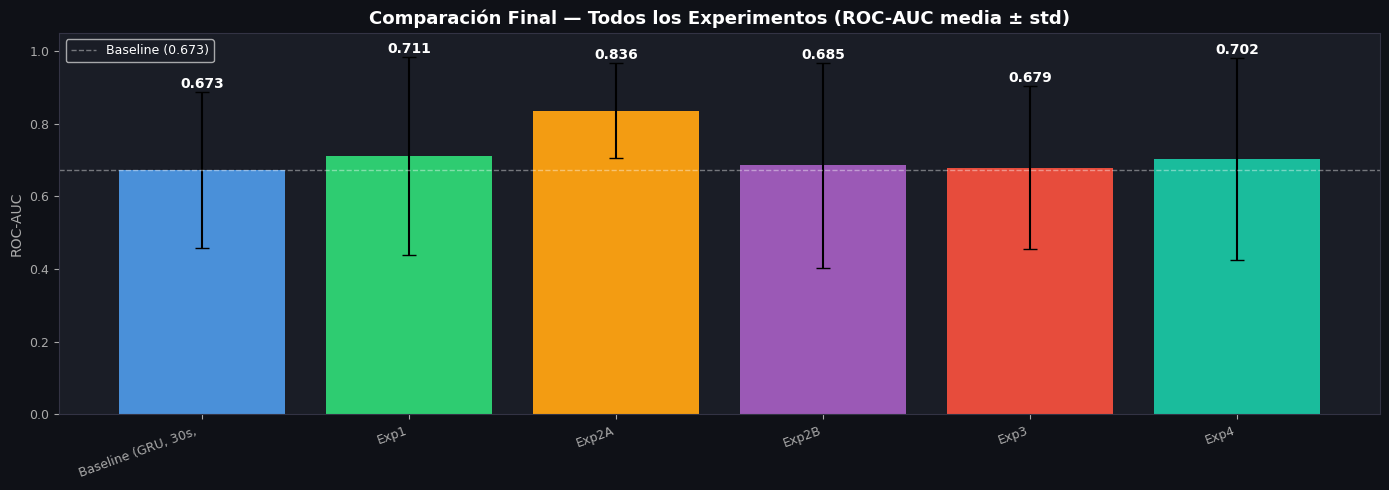

In [ ]:
# Mejor combinación del Exp 1
best_combo_name = list(ablation_results.keys())[
    np.argmax([np.nanmean([ablation_results[c][s]['roc']
               for s in subjs_B]) for c in ablation_results])
]
best_combo_2b = list(exp2_results.keys())[1] 

summary = {
    'Baseline (GRU, 30s, todos)': {s: {'roc': BASELINE_AUC[s]} for s in ALL_SUBJECTS if s in BASELINE_AUC},
    f'Exp1 — {best_combo_name}':  ablation_results[best_combo_name],
    'Exp2A — Solo detectables':   exp2_results.get(list(exp2_results.keys())[0], {}),
    'Exp2B — Detect+Moderados':   exp2_results.get(best_combo_2b, {}),
    'Exp3 — Zona 15s':            exp3_results,
    'Exp4 — Umbral adaptativo':   exp4_results,
}

print('\n' + '='*75)
print('TABLA COMPARATIVA FINAL — TODOS LOS EXPERIMENTOS')
print('='*75)
print(f'{"Experimento":35} {"N sujetos":>10} {"AUC media":>10} {"Std":>8} {"Delta":>8}')
print('-'*75)
base_mean = np.mean(list(BASELINE_AUC.values()))
for exp_name, res in summary.items():
    aucs = [m['roc'] for m in res.values() if not np.isnan(m.get('roc', np.nan))]
    if not aucs: continue
    delta = np.mean(aucs) - base_mean if 'Baseline' not in exp_name else 0
    arrow = '⬆' if delta > 0.01 else ('⬇' if delta < -0.01 else '≈')
    print(f'{exp_name:35} {len(aucs):>10} {np.mean(aucs):>10.3f} '
          f'{np.std(aucs):>8.3f} {delta:>+7.3f} {arrow}')

# Gráfica final comparativa
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0F1117'); ax.set_facecolor('#1A1D26')

exp_labels, exp_means, exp_stds, exp_colors = [], [], [], []
color_list = ['#4A90D9','#2ECC71','#F39C12','#9B59B6','#E74C3C','#1ABC9C']
for i, (exp_name, res) in enumerate(summary.items()):
    aucs = [m['roc'] for m in res.values() if not np.isnan(m.get('roc', np.nan))]
    if not aucs: continue
    exp_labels.append(exp_name.split('—')[0].strip() if '—' in exp_name else exp_name[:20])
    exp_means.append(np.mean(aucs))
    exp_stds.append(np.std(aucs))
    exp_colors.append(color_list[i % len(color_list)])

bars = ax.bar(exp_labels, exp_means, yerr=exp_stds, capsize=5,
              color=exp_colors, edgecolor='none',
              error_kw={'color':'white','linewidth':1.5})
for bar, m, s in zip(bars, exp_means, exp_stds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.01,
            f'{m:.3f}', ha='center', color='white', fontsize=10, fontweight='bold')
ax.axhline(base_mean, color='white', linestyle='--', alpha=0.4, linewidth=1, label=f'Baseline ({base_mean:.3f})')
ax.set_title('Comparación Final — Todos los Experimentos (ROC-AUC media ± std)',
             color='white', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC', color='#AAAAAA')
ax.tick_params(colors='#AAAAAA', labelsize=9)
ax.set_xticklabels(exp_labels, rotation=20, ha='right', color='#AAAAAA')
ax.spines[:].set_color('#333344'); ax.set_ylim(0, 1.05)
ax.legend(facecolor='#1A1D26', labelcolor='white', fontsize=9)
plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/comparacion_final_experimentos.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()